# ANN from scratch

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training the model...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9133 - loss: 0.3006
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9581 - loss: 0.1420
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9682 - loss: 0.1060
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9743 - loss: 0.0855
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9771 - loss: 0.0746
313/313 - 1s - 2ms/step - accuracy: 0.9752 - loss: 0.0795

Test accuracy: 97.52%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


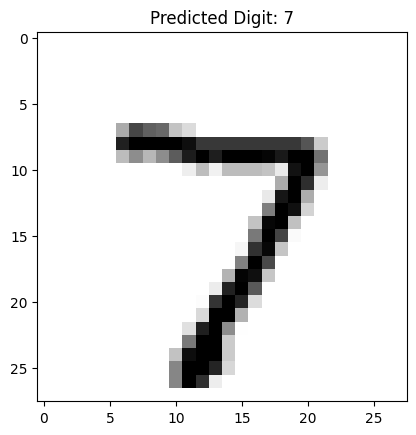

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the MNIST dataset (Digits 0-9)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 2. Data Preprocessing
x_train, x_test = x_train / 255.0, x_test / 255.0

# 3. Build the Architecture
model = models.Sequential([
    # Flatten: Turns the 28x28 pixel grid into a 1D line of 784 pixels
    layers.Flatten(input_shape=(28, 28)),

    # Dense: The "Hidden Layer" where learning happens using relu activation.
    layers.Dense(128, activation='relu'),

    # Dropout: Randomly turns off neurons during training to prevent "overfitting"
    layers.Dropout(0.2),

    # Output Layer: 10 neurons (one for each digit 0-9)
    layers.Dense(10, activation='softmax')
])

# 4. Compile the Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. Train the Model (The Learning Phase)
print("Training the model...")
model.fit(x_train, y_train, epochs=5)

# 6. Evaluate Accuracy on data the model has never seen
test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)
print(f'\nTest accuracy: {test_acc*100:.2f}%')

# 7. Visualizing a Prediction
# Let's pick an image from the test set and see if the model gets it right
prediction = model.predict(x_test)
plt.imshow(x_test[0], cmap=plt.cm.binary)
plt.title(f"Predicted Digit: {np.argmax(prediction[0])}")
plt.show()

# ANN Backpropagation

In [3]:
# Sigmoid activation and its derivative
def sigmoid(x): return 1 / (1 + np.exp(-x))
def sigmoid_derivative(x): return x * (1 - x)

# Input data (X) and Target output (y)
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0], [1], [1], [0]]) # XOR Logic Gate

# Randomly initialize weights
input_layer_neurons = 2
hidden_layer_neurons = 4
output_neurons = 1

wh = np.random.uniform(size=(input_layer_neurons, hidden_layer_neurons))
bh = np.random.uniform(size=(1, hidden_layer_neurons))
wout = np.random.uniform(size=(hidden_layer_neurons, output_neurons))
bout = np.random.uniform(size=(1, output_neurons))

# Learning Rate
lr = 0.1

for epoch in range(10000):
    # --- Forward Prop ---
    hidden_layer_input = np.dot(X, wh) + bh
    hidden_layer_activations = sigmoid(hidden_layer_input)

    output_layer_input = np.dot(hidden_layer_activations, wout) + bout
    output = sigmoid(output_layer_input)

    # --- Backpropagation ---
    # 1. Calculate Error
    error = y - output

    # 2. Calculate Gradient at Output
    d_output = error * sigmoid_derivative(output)

    # 3. Calculate Error at Hidden Layer
    error_hidden_layer = d_output.dot(wout.T)
    d_hidden_layer = error_hidden_layer * sigmoid_derivative(hidden_layer_activations)

    # 4. Update Weights (Gradient Descent)
    wout += hidden_layer_activations.T.dot(d_output) * lr
    wh += X.T.dot(d_hidden_layer) * lr

print("Output after training:\n", output)

Output after training:
 [[0.06826571]
 [0.94230165]
 [0.94603181]
 [0.04828888]]


# CNN

In [4]:
# Prepare data (CNNs need 4D input: [batch, height, width, channels])
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

cnn_model = models.Sequential([
    # Step 1: Feature Extraction (Convolution + Pooling)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Step 2: Classification (The same ANN style as before)
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

print("Training CNN...")
cnn_model.fit(x_train_cnn, y_train, epochs=3)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training CNN...
Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 30ms/step - accuracy: 0.9582 - loss: 0.1363
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 29ms/step - accuracy: 0.9861 - loss: 0.0444
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9900 - loss: 0.0309
